In [1]:
import pandas as pd
import geopandas as gpd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys
from sklearn.metrics.pairwise import euclidean_distances

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

In [2]:
data_old = pd.read_csv('../data/GR_WNV_cases_grid_2010-2021_processed.csv', encoding = enc)
data_new = pd.read_csv('../data/GR_WNV_cases_GRID_2022-2024_processed.csv', encoding = enc)
dataset = pd.concat([data_old, data_new], ignore_index=True)

In [3]:
dataset

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases,dt_placement
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1,NaN
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,κιλκις,μεσοι αποστολοι,CS294,1,NaN
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,πελλας,γιαννιτσα,DE262,1,NaN
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,EB307,1,NaN
4,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καραμπουρνακι,EB308,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2011,NaN,2024,10,9,κεντρικης μακεδονιας,σερρων,ηρακλειας,καρπερη,BT338,1,2024-10-09
2012,NaN,2024,10,10,θεσσαλιας,λαρισας,λαρισαιων,λαρισα,IC260,1,2024-10-10
2013,NaN,2024,10,13,ανατολικης μακεδονιας και θρακης,ροδοπης,κομοτηνης,συμβολα,BN515,1,2024-10-13
2014,NaN,2024,10,21,αττικης,κεντρικου τομεα αθηνων,ζωγραφου,ζωγραφου,PF376,1,2024-10-21


In [4]:
dataset = convert_multiple_cases(dataset, target_col = 'cases')

In [5]:
dataset

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,cases,dt_placement
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1,NaN
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,κιλκις,μεσοι αποστολοι,CS294,1,NaN
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,πελλας,γιαννιτσα,DE262,1,NaN
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,EB307,1,NaN
4,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καραμπουρνακι,EB308,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2031,2019-09-05,2019,9,5,ανατολικης μακεδονιας και θρακης,καβαλας,νεστου,χρυσοχωρι,CP456,1,NaN
2032,NaN,2022,9,2,θεσσαλιας,λαρισας,λαρισαιων,λαρισα,IB260,1,2022-09-02
2033,NaN,2022,9,17,κεντρικης μακεδονιας,θεσσαλονικης,καλαμαριας,καλαμαρια,ED307,1,2022-09-17
2034,NaN,2023,9,3,κεντρικης μακεδονιας,χαλκιδικης,νεας προποντιδας,διονυσιου,FK334,1,2023-09-03


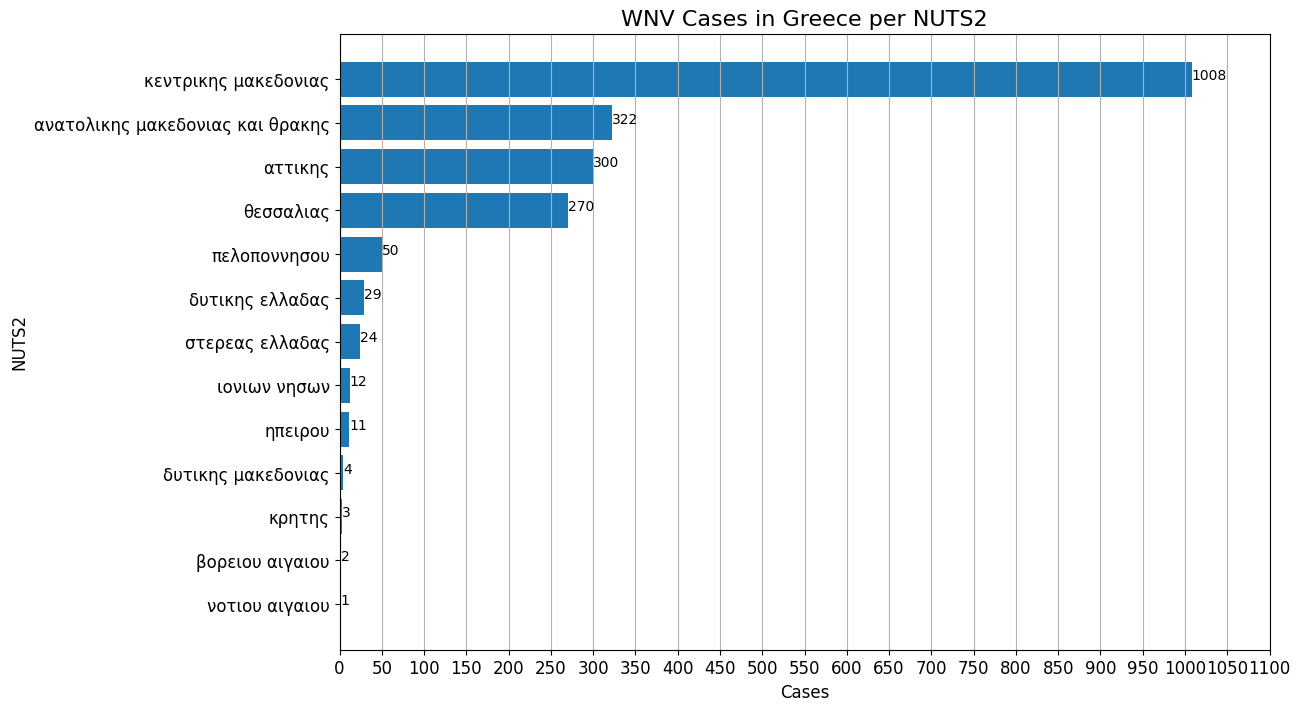

In [6]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (12,8), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 12)
x_t = plt.yticks(nuts2, size = 12)
x_l  = plt.ylabel('NUTS2', size = 12)
y_l =  plt.xlabel('Cases', size = 12)
title = plt.title('WNV Cases in Greece per NUTS2', size = 16)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [7]:
nuts_2_IDS = {'αττικης': 'EL30', 
              'βορειου αιγαιου': 'EL41', 
              'νοτιου αιγαιου': 'EL42', 
              'κρητης': 'EL43', 
              'ανατολικης μακεδονιας και θρακης': 'EL51', 
              'κεντρικης μακεδονιας': 'EL52', 
              'δυτικης μακεδονιας': 'EL53', 
              'ηπειρου': 'EL54', 
              'θεσσαλιας': 'EL61', 
              'ιονιων νησων': 'EL62', 
              'δυτικης ελλαδας': 'EL63',
              'στερεας ελλαδας': 'EL64',
              'πελοποννησου': 'EL65'}

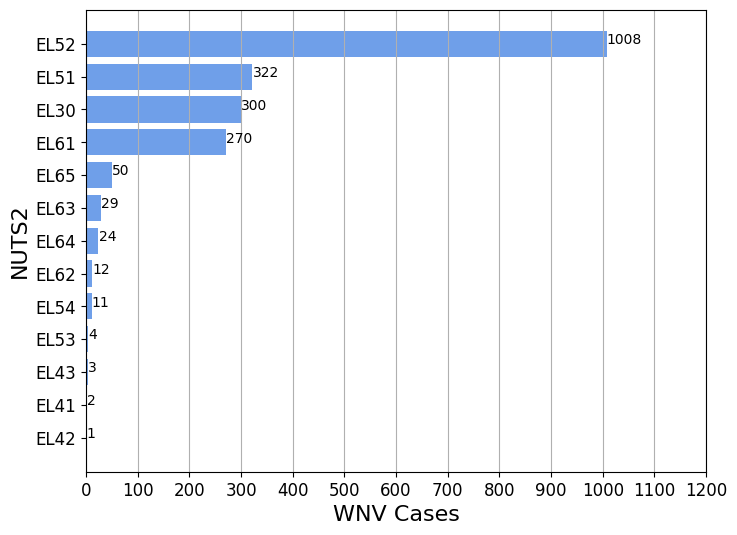

In [ ]:
nuts2 = dataset['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(dataset.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

nuts2_ids = [nuts_2_IDS[key] for key in nuts2 if key in nuts_2_IDS]

cases, nuts2_ids = zip(*sorted(zip(cases, nuts2_ids)))

plt.figure(num = None, figsize = (8,6), facecolor='w', edgecolor='b')
plt.barh(nuts2_ids, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 100), size = 12)
x_t = plt.yticks(nuts2_ids, size = 12)
x_l  = plt.ylabel('NUTS2', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for nuts2_ids, case in zip(nuts2_ids,cases):
    plt.text(case+0.15, nuts2_ids, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [9]:
cases

(1, 2, 3, 4, 11, 12, 24, 29, 50, 270, 300, 322, 1008)

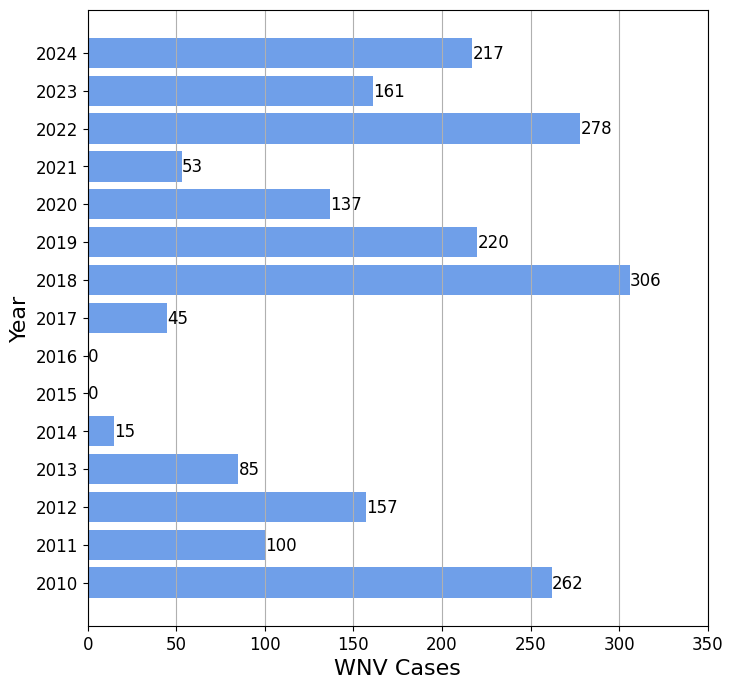

In [12]:
years = [year for year in range(2010, 2025)]
cases = [len(dataset.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (8,8), facecolor='w', edgecolor='b')
plt.barh(years, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 50), size = 12)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 12)
x_l  = plt.ylabel('Year', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()
###########################################################################################

In [13]:
dataset.month.sort_values().unique()

array([ 5,  6,  7,  8,  9, 10], dtype=int64)

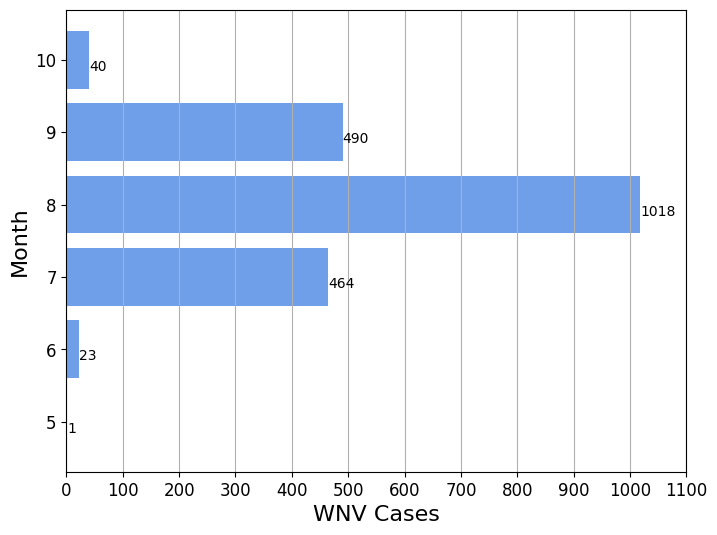

In [16]:
months = [month for month in dataset.month.sort_values().unique()]
cases = [len(dataset.query(f"month == {month}")) for month in months]

plt.figure(num = None, figsize = (8,6), facecolor='w', edgecolor='b')
plt.barh(months, cases, color='#6f9fe9')

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 100), size = 12)
x_t = plt.yticks(np.arange(min(months), max(months) + 1, step = 1), size = 12)
x_l  = plt.ylabel('Month', size = 16)
y_l =  plt.xlabel('WNV Cases', size = 16)
for year, case in zip(months,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 10)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()